# Expense vs Income Classification
### Final Term Project — Data Science Workflow

**Problem statement:** When a user quickly logs a transaction in a personal expense-tracker app
(e.g. *"Uber - 250"*, *"Salary - 50000"*), manually tagging every entry as Income or Expense is
tedious and error-prone. This project builds a classifier that predicts whether a transaction is
an **Income** or an **Expense** from its `Note`, `Amount`, `Mode`, and `Date`, so that data entry
in an app like the one built for the mid-term (expense tracker) could be partially automated.

**Dataset:** [Daily Transactions Dataset](https://www.kaggle.com/datasets/prasad22/daily-transactions-dataset)
by Prasad Patil (Kaggle). 2,461 dummy household transactions recorded in India, 2015–2018.
License: as specified on the Kaggle page. Note: the dataset description states these are
**dummy (synthetic-style) transactions made by an individual**, not real anonymized bank data —
this is an acknowledged limitation of the project (see Section 10).


## 1. Setup

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              classification_report, confusion_matrix)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Data Loading & Provenance (DW-1, DW-2)

- **Source:** Kaggle — `prasad22/daily-transactions-dataset` (v4)
- **Rows:** 2,461 | **Columns:** 8
- **Collection method:** dummy transactions entered by an individual (per dataset description)
- **License:** see Kaggle dataset page


In [2]:
DATA_FILE = Path('Daily Household Transactions.csv')
if not DATA_FILE.exists():
    notebook_file = globals().get('__vsc_ipynb_file__')
    if notebook_file:
        DATA_FILE = Path(notebook_file).with_name('Daily Household Transactions.csv')

if not DATA_FILE.exists():
    raise FileNotFoundError(
        'Could not find Daily Household Transactions.csv. '
        'Place it beside the notebook or in the current working directory.'
    )

df = pd.read_csv(DATA_FILE)
print('Loaded:', DATA_FILE.resolve())
print('Shape:', df.shape)
df.head()


Loaded: /home/ismail-hossain/Downloads/Daily Household Transactions.csv
Shape: (2461, 8)


,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR


## 3. Data Audit (DW-3)

Checks performed: missing values, duplicate rows, target class balance, inconsistent date formats,
and a check for **potential leakage** in the `Category` / `Subcategory` columns.


In [3]:
print('--- Missing values ---')
print(df.isnull().sum())
print()
print('--- Duplicate rows ---')
print(df.duplicated().sum())
print()
print('--- Target distribution (Income/Expense) ---')
print(df['Income/Expense'].value_counts())


--- Missing values ---
Date                0
Mode                0
Category            0
Subcategory       635
Note              521
Amount              0
Income/Expense      0
Currency            0
dtype: int64

--- Duplicate rows ---
9

--- Target distribution (Income/Expense) ---
Income/Expense
Expense         2176
Transfer-Out     160
Income           125
Name: count, dtype: int64


### 3.1 Scope decision: removing `Transfer-Out`

The target column has **3** values: `Expense` (88.4%), `Transfer-Out` (6.5%), `Income` (5.1%).
`Transfer-Out` represents moving money between the user's own accounts/investments — it is
conceptually neither income nor expense. Since our problem statement is specifically
**Income vs Expense**, we drop these 160 rows rather than force them into either class.


In [4]:
df = df[df['Income/Expense'] != 'Transfer-Out'].copy()
df = df.drop_duplicates()
print('Shape after removing Transfer-Out and duplicates:', df.shape)
print(df['Income/Expense'].value_counts())


Shape after removing Transfer-Out and duplicates: (2298, 8)
Income/Expense
Expense    2173
Income      125
Name: count, dtype: int64


### 3.2 Leakage check: dropping `Category`, `Subcategory`, `Currency`

`Category` values (e.g. `Salary`, `Investment`, `Dividend earned on Shares` vs. `Food`,
`Transportation`) were assigned by the original data source **using the same knowledge of
whether a transaction was income or expense**. Using `Category` as a feature would let the
model trivially achieve near-100% accuracy without learning anything generalizable — this is a
classic **label-leakage** feature and is dropped. `Subcategory` is dropped for the same reason.
`Currency` is dropped because it is constant (`INR`) for every row and carries no information.


In [5]:
df = df.drop(columns=['Category', 'Subcategory', 'Currency'])
print(df.columns.tolist())


['Date', 'Mode', 'Note', 'Amount', 'Income/Expense']


## 4. Train/Test Split (DW-5)

The split is done **before** any preprocessing, to avoid leaking information about the test set
into feature engineering. Because the target is imbalanced (~94.6% / 5.4%), we use a
**stratified split** so both sets preserve the same class ratio.


In [6]:
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['Income/Expense'], random_state=RANDOM_STATE
)
print('Train:', train_df.shape, '| Test:', test_df.shape)
print(train_df['Income/Expense'].value_counts(normalize=True))
print(test_df['Income/Expense'].value_counts(normalize=True))


Train: (1838, 5) | Test: (460, 5)
Income/Expense
Expense    0.945593
Income     0.054407
Name: proportion, dtype: float64
Income/Expense
Expense    0.945652
Income     0.054348
Name: proportion, dtype: float64


## 5. Exploratory Data Analysis — TRAIN SET ONLY (DW-4)

All EDA below uses `train_df` only. The test set is not inspected beyond the split step above,
to keep the final evaluation honest.


In [7]:
print(train_df.groupby('Income/Expense')['Amount'].describe())


                 count          mean           std  min   25%     50%  \
Income/Expense                                                          
Expense         1738.0    887.441007   3948.432141  2.0  30.0    85.0   
Income           100.0  23815.713500  28201.812049  2.0  17.0  2250.0   

                     75%       max  
Income/Expense                      
Expense           333.75  100000.0  
Income          51556.00   78298.0  


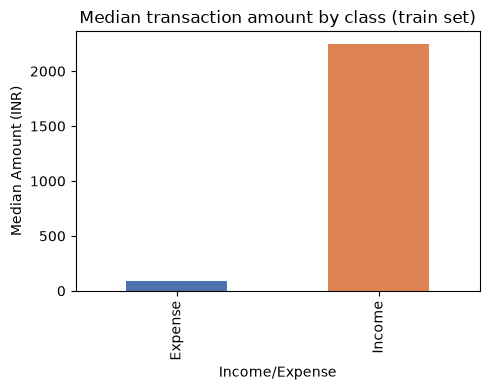

In [8]:
fig, ax = plt.subplots(figsize=(5,4))
train_df.groupby('Income/Expense')['Amount'].median().plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'])
ax.set_ylabel('Median Amount (INR)')
ax.set_title('Median transaction amount by class (train set)')
plt.tight_layout()
plt.savefig('eda_amount_by_class.png', dpi=120)
plt.show()


In [9]:
print(pd.crosstab(train_df['Mode'], train_df['Income/Expense']))


Income/Expense         Expense  Income
Mode                                  
Cash                       835       5
Credit Card                142       0
Debit Card                   2       0
Equity Mutual Fund C         0       1
Recurring Deposit            0       3
Saving Bank account 1      757      89
Saving Bank account 2        2       2


**EDA takeaway:** `Amount` is a strong candidate feature — the median Income transaction
(₹2,250) is roughly 26x larger than the median Expense transaction (₹85). `Mode` is also
informative: `Cash` transactions are almost always expenses.


## 6. Preprocessing — Leakage-Safe (DW-6)

All transformers (`OneHotEncoder`, `TfidfVectorizer`) are **fit on the training set only**, then
applied (`.transform`) to the test set. This prevents test-set statistics/vocabulary from leaking
into training.

Steps:
1. Fill missing `Note` with the placeholder `"unknown"`.
2. Log-transform `Amount` (right-skewed) → `log_amount`.
3. One-hot encode `Mode`.
4. TF-IDF vectorize `Note` (top 50 terms, English stop-words removed).
5. Encode target: `Income` → 1, `Expense` → 0.


In [10]:
train_df = train_df.copy()
test_df = test_df.copy()
train_df['Note'] = train_df['Note'].fillna('unknown')
test_df['Note'] = test_df['Note'].fillna('unknown')

train_df['log_amount'] = np.log1p(train_df['Amount'])
test_df['log_amount'] = np.log1p(test_df['Amount'])

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
mode_train = ohe.fit_transform(train_df[['Mode']])   # fit on TRAIN only
mode_test = ohe.transform(test_df[['Mode']])          # transform only on test
mode_cols = [f'mode_{c}' for c in ohe.categories_[0]]

tfidf = TfidfVectorizer(max_features=50, stop_words='english')
note_train = tfidf.fit_transform(train_df['Note']).toarray()   # fit on TRAIN only
note_test = tfidf.transform(test_df['Note']).toarray()          # transform only on test
vocab_sorted = sorted(tfidf.vocabulary_.items(), key=lambda x: x[1])
note_cols = [f'tfidf_{w}' for w, i in vocab_sorted]

X_train = pd.concat([
    pd.DataFrame(mode_train, columns=mode_cols).reset_index(drop=True),
    train_df[['log_amount']].reset_index(drop=True),
    pd.DataFrame(note_train, columns=note_cols).reset_index(drop=True)
], axis=1)

X_test = pd.concat([
    pd.DataFrame(mode_test, columns=mode_cols).reset_index(drop=True),
    test_df[['log_amount']].reset_index(drop=True),
    pd.DataFrame(note_test, columns=note_cols).reset_index(drop=True)
], axis=1)

y_train = (train_df['Income/Expense'] == 'Income').astype(int).reset_index(drop=True)
y_test = (test_df['Income/Expense'] == 'Income').astype(int).reset_index(drop=True)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)


X_train: (1838, 58) | X_test: (460, 58)


## 7. Baseline Model (DW-7)

A `DummyClassifier` that always predicts the majority class (`Expense`). This tells us what
"doing nothing clever" looks like, and highlights why accuracy alone is a misleading metric on
this imbalanced problem.


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)

acc = cross_validate(baseline, X_train, y_train, cv=cv, scoring=['accuracy','f1'])
print('Baseline CV Accuracy:', acc['test_accuracy'].mean())
print('Baseline CV F1 (Income class):', acc['test_f1'].mean())
print('--> High accuracy but F1 = 0: the baseline NEVER predicts Income.')


Baseline CV Accuracy: 0.9455929392252103
Baseline CV F1 (Income class): 0.0
--> High accuracy but F1 = 0: the baseline NEVER predicts Income.


## 8. Model Development (DW-8)

We compare two models beyond the baseline:
- **Logistic Regression** — simple, interpretable, coefficients show feature influence directly.
- **Random Forest** — captures non-linear interactions between amount/mode/text features.

Both use `class_weight='balanced'` to counter the ~95/5 class imbalance without synthesizing
data (keeps preprocessing leakage-safe and simple to justify).

All tuning below uses **cross-validation on the training set only** — the test set is not
touched in this section.


In [12]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=RANDOM_STATE)
}

for name, model in models.items():
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=['accuracy','f1','precision','recall'])
    print(f'--- {name} ---')
    for m in ['accuracy','f1','precision','recall']:
        print(f'  {m}: {res["test_"+m].mean():.4f}')
    print()


--- Logistic Regression ---
  accuracy: 0.8134
  f1: 0.3260
  precision: 0.2031
  recall: 0.8300

--- Random Forest ---
  accuracy: 0.9451
  f1: 0.5878
  precision: 0.5007
  recall: 0.7200



**Observation:** Logistic Regression's CV accuracy (~81%) is actually *lower* than the
baseline's accuracy (~94.6%) — yet its recall for Income is far higher (~0.83 vs 0). This
illustrates the accuracy paradox on imbalanced data: accuracy alone would wrongly suggest the
baseline is "better". Random Forest achieves the best balance of accuracy and F1, and is
selected for hyperparameter tuning.


In [13]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}
rf = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE)
grid = GridSearchCV(rf, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best CV F1:', grid.best_score_)


Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV F1: 0.6805877813847054


## 9. Final Evaluation — Untouched Test Set, Once (DW-9)

The tuned Random Forest is fit on the full training set and evaluated **exactly once** on the
held-out test set. No further tuning is done based on these results.


In [14]:
best_rf = RandomForestClassifier(**grid.best_params_, class_weight='balanced', random_state=RANDOM_STATE)
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)

baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

lr_final = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr_final.fit(X_train, y_train)
y_pred_lr = lr_final.predict(X_test)

for name, y_pred in [('Baseline', y_pred_base), ('Logistic Regression', y_pred_lr), ('Random Forest (final)', y_pred_rf)]:
    print(f'--- {name} ---')
    print('Accuracy:', accuracy_score(y_test, y_pred))
    print('F1:', f1_score(y_test, y_pred))
    print()

print('Confusion matrix (Random Forest) [rows=actual, cols=predicted], classes=[Expense, Income]:')
print(confusion_matrix(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf, target_names=['Expense','Income']))


--- Baseline ---
Accuracy: 0.9456521739130435
F1: 0.0

--- Logistic Regression ---
Accuracy: 0.7478260869565218
F1: 0.24675324675324675

--- Random Forest (final) ---
Accuracy: 0.9434782608695652
F1: 0.5357142857142857

Confusion matrix (Random Forest) [rows=actual, cols=predicted], classes=[Expense, Income]:
[[419  16]
 [ 10  15]]

              precision    recall  f1-score   support

     Expense       0.98      0.96      0.97       435
      Income       0.48      0.60      0.54        25

    accuracy                           0.94       460
   macro avg       0.73      0.78      0.75       460
weighted avg       0.95      0.94      0.95       460



## 10. Interpretation, Error Analysis & Limitations (DW-10)

### Feature importance


In [15]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.head(10)


log_amount                    0.418486
mode_Cash                     0.113285
mode_Saving Bank account 1    0.105135
tfidf_workplace               0.083913
tfidf_family                  0.044278
mode_Credit Card              0.029667
tfidf_unknown                 0.027384
tfidf_place                   0.022438
tfidf_milk                    0.016662
mode_Saving Bank account 2    0.016388
dtype: float64

### Misclassified examples


In [16]:
test_readable = test_df.reset_index(drop=True).copy()
test_readable['actual'] = y_test
test_readable['predicted'] = y_pred_rf

fn = test_readable[(test_readable.actual==1) & (test_readable.predicted==0)]
fp = test_readable[(test_readable.actual==0) & (test_readable.predicted==1)]
print('False negatives (missed Income):', len(fn))
print(fn[['Mode','Note','Amount']].head(10))
print()
print('False positives (Expense flagged as Income):', len(fp))
print(fp[['Mode','Note','Amount']].head(10))


False negatives (missed Income): 10
                      Mode                 Note  Amount
30   Saving Bank account 1          HDFC Stocks    88.0
39   Saving Bank account 1      Pidilite Stocks    22.0
47   Saving Bank account 2        interest paid    28.0
144  Saving Bank account 1        interest paid   508.0
243                   Cash     Gift from inlaws  2000.0
301                   Cash              unknown    20.0
325  Saving Bank account 1     Redington Stocks   180.0
354  Saving Bank account 1    Tata Steel Stocks   180.0
363  Saving Bank account 1  Asian paints Stocks    43.0
382  Saving Bank account 1       return deposit  4800.0

False positives (Expense flagged as Income): 16
                      Mode                       Note    Amount
6    Saving Bank account 1           Tours and Travel  20000.00
9    Saving Bank account 1       splitwise settlement    607.00
48   Saving Bank account 1            Metz 32 inch TV  20500.00
75   Saving Bank account 1    travels - Mum

### Discussion

- **`log_amount` is the single most important feature (~41%)**, consistent with the EDA finding
  that Income transactions tend to involve much larger amounts.
- **False negatives** are dominated by small-amount stock/investment income (e.g. "HDFC Stocks",
  "Pidilite Stocks") — the model under-weights these because (a) the amounts are small, which it
  associates with expenses, and (b) individual stock names are too sparse in the TF-IDF
  vocabulary for the model to generalize a "stock → income" rule.
- **False positives** are dominated by large one-off expenses (electronics, travel) and the word
  *"Family"*, which the model associates with income because the training data contains phrases
  like *"From Family"* (income) but not enough contrasting examples of *"to Family"* (expense) to
  distinguish direction.
- **Limitations:** (1) the dataset is explicitly described as dummy/synthetic data entered by one
  individual, so results may not generalize to other users' spending habits; (2) the Income class
  has only 125 examples total, limiting how well any model can learn rarer income patterns; (3)
  no explicit handling of "from X" vs "to X" directionality in the text features — a known,
  acknowledged gap rather than something we tuned away after seeing test results.
